[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammedmka95/Medad-CV-Bootcamp/blob/main/Week3/Week_3_Traditional_CV_EdgeDetection_Motion_Filtering.ipynb)

<div dir="rtl">

# مسار الرؤية الحاسوبية

---

</div>

<div dir="rtl">

# الأسبوع 3: الرؤية الحاسوبية الكلاسيكية - كشف الحواف، الفلترة، وكشف الحركة

---
**المُعد/المؤلف:** [محمد حاج فارس](https://www.linkedin.com/in/mohres/)

---
ستتعلم في هذا الأسبوع الأدوات الأساسية للرؤية الحاسوبية قبل التعلم العميق: كيف يكتشف الحاسوب حواف الأجسام (Canny)، وكيف نُحسّن جودة الصور بالفلاتر، وكيف نرصد حركة الأجسام في الفيديو، وهي مهارات ضرورية لفهم كيفية عمل الأنظمة البصرية وبناء تطبيقات حقيقية.

---

</div>

<div dir="rtl">

## لماذا يهمنا هذا الموضوع؟

هذه التقنيات ليست قديمة بل أساسية: تُستخدم اليوم في السيارات الذاتية القيادة، وكاميرات المراقبة، وتطبيقات الهاتف، والتصوير الطبي. كما أنها أخفّ وأسرع من نماذج التعلم العميق في كثير من الحالات.
فهمك لهذه الأساسيات يمنحك ميزتين: القدرة على بناء حلول سريعة وفعّالة دون الحاجة لنماذج ضخمة ومكلفة، وفهم أعمق لما يحدث "تحت الغطاء" في نماذج الرؤية الحديثة المبنية على الشبكات العصبية.

**التطبيقات الواقعية:**

- **رقمنة الوثائق:** كشف حواف الورقة لاقتطاعها تلقائياً + فلترة لتنظيف الصورة قبل OCR — مفيد لرقمنة السجلات المدنية والعقارية.
- **كشف الشقوق في المباني المتضررة:** Edge Detection لتحديد التشققات في الجدران لتقييم سلامة المباني قبل الترميم.
- **تحسين صور الأشعة الطبية:** فلاتر لإزالة الضوضاء وإبراز الحواف، يساعد الأطباء على رؤية أوضح في المشافي ذات الأجهزة القديمة.
- **كاميرات أمنية بسيطة:** Motion Detection فقط لتسجيل المقاطع عند الحركة وتوفير مساحة التخزين والكهرباء.
- **عدّ المركبات في الشوارع:** Motion Detection لإحصاء حركة المرور في دمشق وحلب لدراسات النقل والتخطيط العمراني.
- **مراقبة المحاصيل:** كشف حواف الحقول من صور الدرونز وفلترة الصور لتقدير المساحات المزروعة.
- **ترميم الصور القديمة:** فلاتر لإزالة الخدوش والضوضاء من الصور العائلية والوثائقية التالفة.

</div>

<div dir="rtl">

## المفاهيم الأساسية

| المفهوم | التعريف |
|---|---|
| الصورة | مصفوفة من الأرقام تمثّل شدة الضوء عند كل نقطة (0 = أسود، 255 = أبيض). |
| البكسل (Pixel) | أصغر وحدة في الصورة — خلية واحدة من المصفوفة تحمل قيمة الإضاءة. |
| الحافة (Edge) | منطقة تغيّر مفاجئ وسريع في شدة الإضاءة بين بكسل وآخر. |
| التدرّج (Gradient) | مشتق الصورة — يقيس معدّل ومقدار التغيّر في شدة الإضاءة. |
| النواة (Kernel) | مصفوفة صغيرة (مثلاً 3×3) تُمرَّر فوق الصورة لتطبيق تأثير معيّن كالتنعيم أو إبراز الحواف. |
| الالتفاف (Convolution) | عملية ضرب النواة بالمنطقة المقابلة من الصورة لإنتاج قيمة بكسل جديدة. |
| العتبة (Threshold) | قيمة حدّية تُفرز البكسلات إلى مجموعتين (مثلاً: حافة / لا حافة). |
---
<div align="center">
<img src="https://raw.githubusercontent.com/mohres/aleppo-vision-course-assets/master/images/pixel.png">

صورة مكونة من 4x4 بكسل
</div>

$$
\begin{bmatrix}
71 & 182 & 212 & 243 \\
138 & 212 & 230 & 243 \\
185 & 232 & 241 & 243 \\
229 & 239 & 241 & 241
\end{bmatrix}
$$

ما يقابل الصورة بالصيغة الرقمية. لاحظ كلما كان اللون أقرب للأبيض اقتربت القيمة من 255 وكلما اقتربت من اللون الأسود أصبحت القيم أصغر واقتربت من الصفر
</div>


<div dir="rtl">

## الشرح النظري

---

## 1- كشف الحواف باستخدام Canny

### ما هي "الحافة" أصلاً؟

عرّفنا الحافة في جدول المفاهيم أعلاه — السؤال الأهم هو: **كيف نعلّم الحاسوب اكتشافها؟** انظر للصورة التالية: عقلك يفصل القطة عن الخلفية لحظياً، لكن الحاسوب يحتاج خطوات رياضية لتحقيق نفس النتيجة.

<div align="center">
<img src="https://raw.githubusercontent.com/mohres/aleppo-vision-course-assets/master/images/edge-detection-example-1.jpg" width="700">
</div>

### كيف يكتشف الحاسوب الحواف رياضياً؟

الفكرة الأساسية: **الحافة = تغيّر كبير في قيمة البكسلات = مشتقّ كبير**.


### الالتفاف (Convolution) — الآلية المشتركة لجميع الفلاتر

> 💡 **مرشح غاوس** هو فلتر تنعيم يُقلّل الضوضاء بضبابية ذكية تعتمد على التوزيع الطبيعي. ستجد الشرح الكامل — المعادلة، نواة الأوزان، ومعامل سيجما — في **قسم الفلترة والمعالجة المسبقة** أدناه. ما يهمنا هنا هو آلية عمل الالتفاف التي يشترك فيها غاوس مع كل الفلاتر الأخرى:

#### كيف يعمل الالتفاف هندسياً؟
العملية تعتمد على مصفوفة صغيرة تُعرَف باسم (Kernel/نواة). تمر هذه النواة فوق كل بكسل في الصورة وتجري عملية رياضية تسمى الالتفاف (Convolution)

<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/1/19/2D_Convolution_Animation.gif">
</div>

<div align="center">
<img src="https://spatial-lang.readthedocs.io/en/legacy/_images/conv2d.gif">
</div>

الـ GIF في الأعلى يوضح الفكرة العامة للالتفاف؛ حيث يضرب الفلتر قيم البكسلات الحالية في أوزانه الخاصة، ثم يجمعها ليخرج بقيمة جديدة للبكسل المركزي في الصورة الناتجة.

---
### Sobel Operator - معامل/مرشّح سوبل

وظيفته الأساسية هي العثور على الحواف والخطوط الفاصلة في الصورة عن طريق حساب التدرّج (Gradient) في الاتجاهين الأفقي والعمودي باستخدام التفاضل:

$$G_x = \frac{\partial I}{\partial x}, \quad G_y = \frac{\partial I}{\partial y}$$

ثم نحسب **شدة التدرّج (المحصلة)** و**اتجاهه** عبر القوانين التالية:

$$|G| = \sqrt{G_x^2 + G_y^2}, \quad \theta = \arctan\left(\frac{G_y}{G_x}\right)$$

#### كيف نحسب هذا التفاضل الرقمي؟
الصور في الحاسوب ليست دوالاً مستمرة (Continuous) ذات منحنيات ناعمة، بل هي بكسلات منفصلة (Discrete). لذلك، يؤول التفاضل هنا إلى عملية رياضية تسمى **الالتفاف (Convolution)**، حيث نمرر مصفوفات سوبل الأفقية ($G_x$) والعمودية ($G_y$) فوق بكسلات الصورة لحساب الفروقات مباشرة:

$$
G_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix}, \quad
G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}
$$

لو أخذنا مصفوفة التدرج الأفقية ($G_x$) كمثال، ستلاحظ سر تركيبها الذكي:
* **العمود الأيسر:** يُضرب في قيم سالبة (لطرح الجانب الأيسر).
* **العمود الأوسط:** يُضرب في صفر (لإهمال بكسلات المركز تماماً).
* **العمود الأيمن:** يُضرب في قيم موجبة (لجمع الجانب الأيمن).

> **ملاحظة ذكية:** تم ضرب البكسل المحاذي للمركز في ($2$ و $-2$) لإعطائه وزناً وأهمية أكبر في الحساب، مما يمنح الفلتر قدرة مدمجة على تنعيم الصورة وتقليل التشويش أثناء كشف الحواف.

النتيجة الرياضية النهائية لتطبيق هذه المصفوفة هي طرح الجانب الأيسر من الأيمن ($\text{Right} - \text{Left}$)، وهو المفهوم الفعلي للاشتقاق وحساب الفروقات في العالم الرقمي.


---

### خوارزمية Canny — الخطوات الخمس

تُعتبر خوارزمية **Canny** المعيار الذهبي لكشف الحواف في رؤية الحاسوب منذ ابتكارها عام 1986، وهي لا تعتبر فلترًا مستقلًا بل "منظومة متكاملة" تمر بخمس مراحل متتالية:

| المرحلة | الهدف | الأداة والآلية |
| :--- | :--- | :--- |
| **1. تنعيم الصورة** | إزالة الضوضاء والتشويش | فلتر Gaussian |
| **2. حساب التدرّجات** | إيجاد أماكن التغيّرات الحادة | مرشّحات Sobel ($G_x, G_y$) |
| **3. كبت غير الأعظمي (NMS)** | جعل الحواف رقيقة جداً (بمساحة بكسل واحد) | مقارنة البكسل بجيرانه في اتجاه التدرج وإلغاء الباقي |
| **4. العتبة المزدوجة (Double Threshold)** | تصنيف الحواف إلى (قوية، ضعيفة، مهملة) | تحديد حديّن لشدة الإضاءة (High / Low) |
| **5. تتبع الحواف بالـ Hysteresis** | ربط الحواف الضعيفة بالقوية للتأكد من صحتها | الحفاظ على الحواف الضعيفة فقط المتصلة بحافة قوية |

#### شرح الخطوات 3–5 بالتفصيل

* **كبت غير الأعظمي (Non-maximum Suppression - NMS):** تهدف إلى ترقيق الحواف (جعل عرضها بكسل واحد فقط). تقوم الخوارزمية بالنظر إلى زاوية اتجاه التدرج ($\theta$) التي حسبناها في سوبل، وتحافظ فقط على البكسلات التي تمثل "القمة الحقيقية" للحافة، بينما تقوم بإلغاء (كبت) البكسلات المجاورة لها.
* **عتبة مزدوجة (Double Thresholding):** تصنف البكسلات المتبقية إلى ثلاثة أنواع لحماية الحواف الحقيقية من الاختفاء:
  * بكسلات فوق العتبة العليا (High) $\leftarrow$ **حواف قوية ومؤكدة**.
  * بكسلات بين العتبتين $\leftarrow$ **حواف ضعيفة** (نحتاج للتأكد منها في الخطوة التالية).
  * بكسلات تحت العتبة الدنيا (Low) $\leftarrow$ **تُحذف تماماً**.
* **تتبع الحواف بالـ Hysteresis:** هي مرحلة "الفصل والتحقق"؛ حيث تقوم الخوارزمية بفحص الحواف الضعيفة، فإذا كانت متصلة ماديًا بحافة قوية، تحافظ عليها وتعتبرها حافة حقيقية. أما إذا كانت معزولة، فتُحذف باعتبارها تشويشاً عابراً.

---

> 💡 **ملاحظة تمهيدية أساسية:** الخطوة الصفرية وقبل البدء بالخوارزمية هي **تحويل الصورة الملونة إلى صورة بتدرج رمادي (Grayscale)**.
>
> **لماذا؟**
> 1. **الحواف تعتمد على السطوع:** خوارزميات كشف الحواف تبحث عن الانتقال المفاجئ من الظلام إلى الضوء، والألوان (أحمر، أخضر، أزرق) لا تضيف قيمة برمجية هنا، بل تشتت الحسابات.
> 2. **توفير 66% من الجهد:** الصورة الملونة تتكون من 3 مصفوفات ألوان، بينما الرمادية مصفوفة واحدة. تحويلها للرمادي يقلل العمليات الرياضية إلى **الثلث**، مما يجعل الخوارزمية سريعة جداً.

---

#### 🧠 فكّر معي: لماذا نستخدم Gaussian (الخطوة 1) قبل Sobel (الخطوة 2)؟

مرشح سوبل حساس جداً للـ Noise (التشويش الرقمي). إذا كانت الصورة تحتوي على نقاط صغيرة عشوائية أو بكسلات تالفة، سيعتبرها سوبل قفزات مفاجئة في الألوان ويترجمها على أنها "حواف صغيرة"، مما يجعل النتيجة مليئة بنقاط بيضاء مزعجة ومخترعة.

لذلك، نقوم بـ **تغبيش الصورة بغاوس أولاً** لدمج البكسلات الشاذة وتنظيفها، ثم نطبق سوبل لنحصل على الحواف الحقيقية والنظيفة فقط.

---

</div>


<div dir="rtl">

## التدريبات العملية

---

فيما يلي مثال عملي لمعالجة صورة والانتقال  خطوة بخطوة خلال عدة مراحل للوصول للنتيجة النهائية لاستخراج الحواف من الصورة

</div>

In [ ]:
# Install libraries for correct Arabic text rendering in Matplotlib
%%capture
%pip install arabic_reshaper python-bidi

In [ ]:
import arabic_reshaper
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

from bidi.algorithm import get_display

# Helper function to fix Arabic text for Matplotlib plots
def fix_arabic_text_for_plot(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

<div dir="rtl">

### تحميل وعرض الصورة الأصلية

</div>

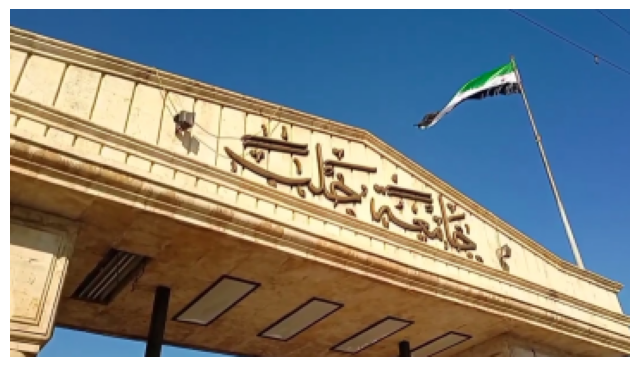

In [ ]:
# URL of the image
image_url = "https://raw.githubusercontent.com/mohres/aleppo-vision-course-assets/master/images/aleppo-uni.jpg"

# Download the image
response = requests.get(image_url)
image_np = np.array(bytearray(response.content), dtype=np.uint8)
img_bgr = cv2.imdecode(image_np, cv2.IMREAD_COLOR)

# Resize the image for better display and processing
scale_percent = 50  # percent of original size
width = int(img_bgr.shape[1] * scale_percent / 100)
height = int(img_bgr.shape[0] * scale_percent / 100)
dim = (width, height)

img_bgr = cv2.resize(img_bgr, dim, interpolation=cv2.INTER_AREA)

# Convert BGR to RGB for matplotlib display
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


# ----- Show original image -----
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

<div dir="rtl">

### 0. حول الصورة الملونة للتدرّج الرمادي

</div>

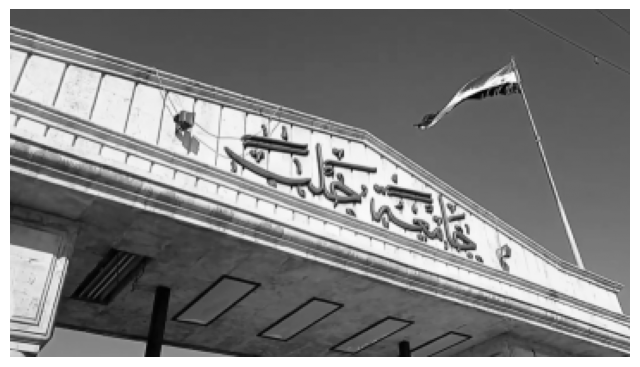

In [ ]:
# الخطوة الصفرية: تحويل الصورة إلى تدرج رمادي (Grayscale)
# لماذا؟ كشف الحواف يعتمد على السطوع فقط — الألوان لا تضيف قيمة وتُشتّت الحسابات
# والفائدة العملية: توفير 66% من الجهد الحسابي (مصفوفة واحدة بدل 3 مصفوفات ألوان)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# ----- Show grayscale image -----
plt.figure(figsize=(8, 6))
plt.imshow(img_gray, cmap='gray')
plt.axis('off')
plt.show()

<div dir="rtl">

### 1. تنعيم الصورة (Gaussian Blur)

</div>

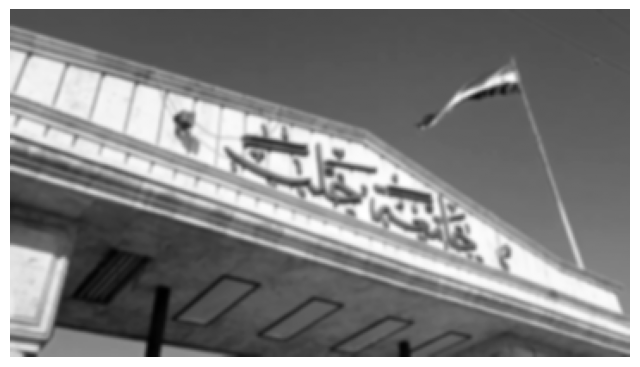

تم تنعيم الصورة.


In [ ]:
# Apply Gaussian blur to smooth the image
# The kernel size (5,5) and sigmaX=0 are common choices.
img_smoothed = cv2.GaussianBlur(img_gray, (5, 5), 0)

plt.figure(figsize=(8, 6))
plt.imshow(img_smoothed, cmap='gray')
# plt.title(fix_arabic_text_for_plot('بعد تطبيق فلتر Gaussian (تنعيم الصورة)'))
plt.axis('off')
plt.show()

print('تم تنعيم الصورة.')

<div dir="rtl">

### 2. حساب التدرّجات (Sobel Filters)

</div>

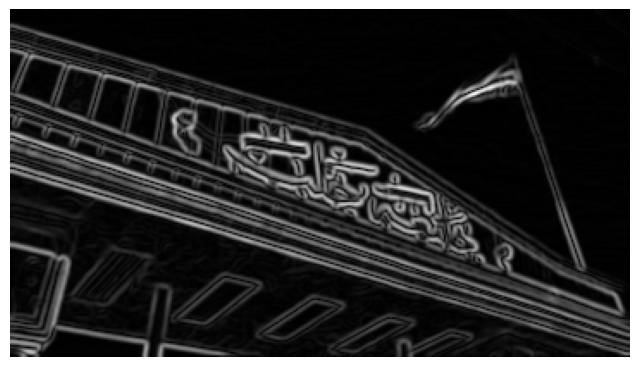

تم حساب شدة التدرجات.


In [ ]:
# Calculate gradients using Sobel filters
# The ddepth=-1 means the output image will have the same depth as the input.
# The ksize=3 is the size of the Sobel kernel.
grad_x = cv2.Sobel(img_smoothed, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(img_smoothed, cv2.CV_64F, 0, 1, ksize=3)

# Calculate the magnitude of the gradient
grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)

# Normalize the gradient magnitude for display
grad_magnitude_display = cv2.normalize(grad_magnitude, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

plt.figure(figsize=(8, 6))
plt.imshow(grad_magnitude_display, cmap='gray')
# plt.title(fix_arabic_text_for_plot('شدة التدرّج بعد تطبيق مرشحات Sobel'))
plt.axis('off')
plt.show()

print('تم حساب شدة التدرجات.')

<div dir="rtl">

### 3–5. كبت الأعظمي، العتبة المزدوجة، وتتبع الحواف

> 🛠️ **ملاحظة برمجية:** في مكتبة OpenCV، تُنفذ الخطوات الثلاث الأخيرة (NMS + Double Threshold + Hysteresis) مدمجةً مع خطوة سوبل تلقائياً داخل دالة واحدة: `cv2.Canny`. كل ما نحتاجه عملياً هو تمرير الصورة المنعمة وتحديد العتبتين العليا والدنيا — راجع الشرح التفصيلي في قسم النظري أعلاه.

</div>

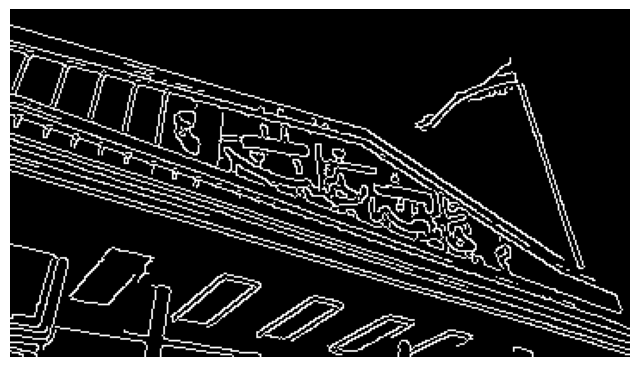

تم تطبيق الخوارزمية بنجاح.


In [ ]:
# تطبيق خوارزمية Canny الكاملة
# (الدالة تحسب سوبل داخلياً ثم تطبق الـ NMS، العتبة المزدوجة، والـ Hysteresis)

# العتبة الأولى (50) للحواف الضعيفة، والثانية (150) للحواف القوية
# النسبة الشائعة والموصى بها بين العتبة الدنيا والعليا هي 1:2 أو 1:3
low_threshold = 50
high_threshold = 150

edges = cv2.Canny(img_smoothed, low_threshold, high_threshold)

# عرض النتيجة النهائية
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
# plt.title(fix_arabic_text_for_plot('النتيجة النهائية لكشف الحواف بواسطة Canny'))
plt.axis('off')
plt.show()

print('تم تطبيق الخوارزمية بنجاح.')

<div dir="rtl">

---

## 2 - الفلترة والمعالجة المسبقة (Filters & Preprocessing)

### لماذا نُعالج الصورة قبل أي شيء آخر؟

الصور الحقيقية التي تلتقطها الكاميرات ليست مثالية أبدًا؛ فهي تحتوي على **ضوضاء (Noise)** ناتجة عن حرارة المستشعر، أو إضاءة سيئة، أو اهتزاز أثناء التصوير. خوارزميات الذكاء الاصطناعي ورؤية الحاسوب حساسة جداً لهذه العيوب، وتعتبر خطوة **الفلترة (Filtering)** بمثابة عملية التنظيف والترتيب الإلزامية للصورة قبل البدء بأي تحليل أو استخراج للحواف.

---

### الفلاتر الشائعة

#### أ) فلتر Gaussian (التنعيم والضبابية الذكية)
> 🔗 **ملاحظة:** رأيتَ هذا الفلتر في العمل مسبقاً كخطوة التنعيم (الخطوة الأولى) في خوارزمية **Canny** — هنا ستفهم بالضبط كيف يعمل داخلياً.

يُستخدم لإزالة الضوضاء العامة (مثل الضوضاء البيضاء المنتشرة خفيفةً في الصورة). ميزته أنه يحافظ على البنية العامة للصورة دون تشويه معالمها الأساسية عبر توزيع أوزان المصفوفة تدريجياً اعتماداً على المعادلة الرياضية التالية:

$$
G(x, y) = \frac{1}{2\pi\sigma^2} \, e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$

إذا نظرنا إلى الأرقام داخل نواة غاوس (مثل مصفوفة 3x3 أو 5x5)، ستلاحظ أن الرقم الأكبر دائماً في المركز (المنتصف)، وتبدأ الأرقام بالانخفاض كلما اتجهت نحو الأطراف:

<div align="center">
<img src="https://www.researchgate.net/profile/Oleg-Shipitko/publication/325768087/figure/fig2/AS:637519863508992@1529007988866/Discrete-approximation-of-the-Gaussian-kernels-3x3-5x5-7x7.png">
</div>

هذا التوزيع يضمن أن البكسلات القريبة جداً من المركز تؤثر بقوة على النتيجة النهائية، بينما البكسلات البعيدة يكون تأثيرها ضئيلاً، مما يعطي نتوءاً ناعماً وضبابية طبيعية تشبه تماماً ما تراه عين الإنسان عندما تفقد التركيز (Out of focus).

#### درجة التغبيش ومعامل سيجما ($\sigma$)

التحكم في قوة الفلتر تعتمد على معامل يسمى Standard Deviation ويرمز له بـ ($\sigma$ - سيجما).كلما زادت قيمة سيجما، زاد عرض منحنى غاوس، وتوزعت الأوزان على مساحة أكبر، مما يعطي تغبيشاً أقوى وأقرب للمظهر الضبابي الشديد.

<div align="center">
<img src="https://ned.ipac.caltech.edu/level5/Leo/Figures/figure3.jpeg">
</div>

<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/62/Cappadocia_Gaussian_Blur.svg/960px-Cappadocia_Gaussian_Blur.svg.png" width="350">
</div>


> 💡 **تذكير:** كما شرحنا في قسم الالتفاف أعلاه، النواة تعامل كل بكسل كمركز إحداثيات (0,0)، وتحسب قيمته الجديدة من المزج المرجّح للبكسلات المجاورة — في مرشح Gaussian يزداد التأثير كلما اقتربنا من المركز تبعاً لقيم سيجما.

#### ب) فلتر الوسيط (Median)

هذا الفلتر ذكي جداً ومختلف؛ فهو لا يقوم بأي عمليات ضرب، ولا يحسب المتوسط الحسابي (Average)، بل يعتمد بالكامل على **الترتيب الإحصائي**. تقوم الخوارزمية بترتيب بكسلات المنطقة المستهدفة تصاعدياً من الأصغر إلى الأكبر، ثم تختار الرقم الذي يقع في **المنتصف (الوسيط - Median)** تماماً وتضعه كقيمة جديدة للبكسل المركزي.



تخيل أن لدينا جزءاً من صورة بحجم $3 \times 3$، وتعرض هذا الجزء لـ **ضوضاء الملح (نقطة بيضاء ناصعة قيمتها 255)** في المنتصف، بينما بقية البكسلات المحيطة به تمثل لوناً رمادياً داكناً (قيمها قريبة من 20):

$$
\text{Image Patch} = \begin{bmatrix} 22 & 20 & 18 \\ 25 & \mathbf{255} & 21 \\ 19 & 23 & 22 \end{bmatrix}
$$

إذا طبقنا فلتر غاوس، فإن الرقم `255` سيُجمع مع بقية الأرقام ويقسم عليها، مما يؤدي إلى تلطيخ المنطقة وتوزيع اللون الأبيض على الجيران ليظهر غباش مزعج.

أما **فلتر الوسيط** فيتصرف كالتالي:

1. **تجميع البكسلات:** نأخذ القيم التسعة ونضعها في قائمة واحدة:
   $$\{22, 20, 18, 25, 255, 21, 19, 23, 22\}$$

2. **الترتيب التصاعدي:** نرتب الأرقام من الأصغر إلى الأكبر:
   $$\{18, 19, 20, 21, \mathbf{22}, 22, 23, 25, 255\}$$

3. **اختيار الوسيط:** نبحث عن الرقم الذي يقع في المنتصف تماماً (العنصر الخامس في قائمة من 9 عناصر)، وهو الرقم **`22`**.

4. **النتيجة النهائية:** يتم استبدال النقطة البيضاء التالفة (`255`) بالقيمة الطبيعية للمحيط (`22`)، فتختفي الضوضاء تماماً كأنها لم تكن!



ضوضاء الملح والفلفل (Salt and Pepper Noise) تنتج قيم بكسلات متطرفة جداً؛ إما سوداء تماماً (`0`) أو بيضاء تماماً (`255`).
عند ترتيب الأرقام تصاعدياً، تنجرف هذه القيم المتطرفة تلقائياً إلى **أقصى أطراف القائمة** (إما في البداية كأصفار أو في النهاية كـ 255)، وبالتالي **يستحيل** أن يتم اختيارها كقيمة وسيطة للمنتصف. هذا الذكاء الإحصائي يجعله الفلتر الأمثل لمسح هذه النقاط الشاذة والحفاظ على تباين الصورة الأصلي.

<Image src="https://raw.githubusercontent.com/mohres/aleppo-vision-course-assets/master/images/median-filter-example.png" alt="مقارنة لصورة تحتوي على ضوضاء الملح والفلفل قبل وبعد إزالتها بكفاءة عالية باستخدام فلتر الوسيط Median Filter" caption="تأثير فلتر الوسيط (Median) في مسح بكسلات الملح والفلفل الشاذة تماماً وإعادة الصورة لطبيعتها" />

---

#### ج) فلتر Laplacian (إبراز الحواف الشامل)
بينما كان معامل سوبل يحسب الحواف في اتجاه واحد (إما أفقي أو عمودي)، يقوم فلتر لابلاسيان بحساب **المشتقة الثانية** للصورة. هذا يعني أنه يكتشف التغير المفاجئ في الألوان في **جميع الاتجاهات دفعة واحدة** وبمصفوفة واحدة ثابتة:

$$
K_{Laplacian} = \begin{bmatrix} 0 & -1 & 0 \\ -1 & 4 & -1 \\ 0 & -1 & 0 \end{bmatrix}
$$

تتميز هذه المصفوفة بأن مجموع عناصرها يساوي صفر، مما يعني أنها تحول كل المناطق ذات اللون الثابت والناعم إلى أسود تام، وتضيء فقط الأماكن التي تشهد تغيراً حاداً في الألوان (الحواف الشاملة).

<Image src="https://raw.githubusercontent.com/mohres/aleppo-vision-course-assets/master/images/laplacian-filter-example.png" />

---

### 📌 قاعدة ذهبية لكل مهندس رؤية حاسوبية

> ⚠️ **لا يوجد فلتر يسمى "الفلتر الأفضل مطلقا"**
>
>  معالجة الصور تعتمد على اختيار الأداة المناسبة للمشكلة المناسبة:
> * **Gaussian Filter:** تستخدمه عندما تكون الصورة بها غباش أو ضوضاء طبيعية ناعمة منتشرة في كل مكان.
> * **Median Filter:** تستخدمه إذا رأيت بكسلات شاذة تالفة (نقاط بيضاء وسوداء حادة).
> * **Laplacian Filter:** تستخدمه عندما لا يهمك تنعيم الصورة، بل تبحث عن رسم سريع ومباشر لخطوط الحواف البارزة في كافة الاتجاهات معاً.

</div>

---

<div dir="rtl">

## 3 - كشف الحركة (Motion Detection)

### الفكرة الجوهرية

في عالم الفيديو، الحركة ليست سوى عبارة عن سلسلة من الصور الثابتة المتتالية (تسمى إطارات أو **Frames**) تُعرض بسرعة. إذا قمنا بطرح مصفوفة الإطار الحالي من مصفوفة الإطار السابق، فإن الأجزاء الثابتة (مثل الجدران والشوارع) ستلغي بعضها وتصبح قيمتها صفراً (سوداء)، بينما تضيء فقط البكسلات التي شهدت تغيراً في قيمها بسبب مرور جسم متحرك.

**الفرق بين إطارين = الحركة**

 هذا المبدأ البسيط هو حجر الأساس لكاميرات المراقبة الذكية وأنظمة المرور ومستشعرات الإنذار.

---

### الطريقة 1: فرق الإطارات المتتالية (Frame Differencing)

هي أبسط وأسرع طريقة على الإطلاق. نقوم بطرح الإطار الحالي عند الزمن ($t$) من الإطار الذي سبقه مباشرة عند الزمن ($t-1$) ونأخذ القيمة المطلقة للفروقات:

$$D(x, y, t) = |I(x, y, t) - I(x, y, t-1)|$$

ولأن الفروقات الخفيفة قد تظهر بسبب الضوضاء، نطبق عتبة رقمية (**Threshold**) لتصفية النتيجة؛ فإذا كان التغير أكبر من قيمة العتبة $T$ نعتبرها حركة حقيقية ($1$ - لون أبيض)، وإلا نعتبرها بكسلات ثابتة ($0$ - لون أسود):

$$M(x, y, t) = \begin{cases} 1 & \text{if } D(x, y, t) > T \\ 0 & \text{otherwise} \end{cases}$$

* **العيب الرئيسي:** إذا توقف الجسم عن الحركة لثانية واحدة، يختفي تماماً من الشاشة لأن الفرق بين الإطارين يصبح صفراً. كما أنها حساسة جداً لاهتزاز الكاميرا وتغير الإضاءة المفاجئ.

</div>


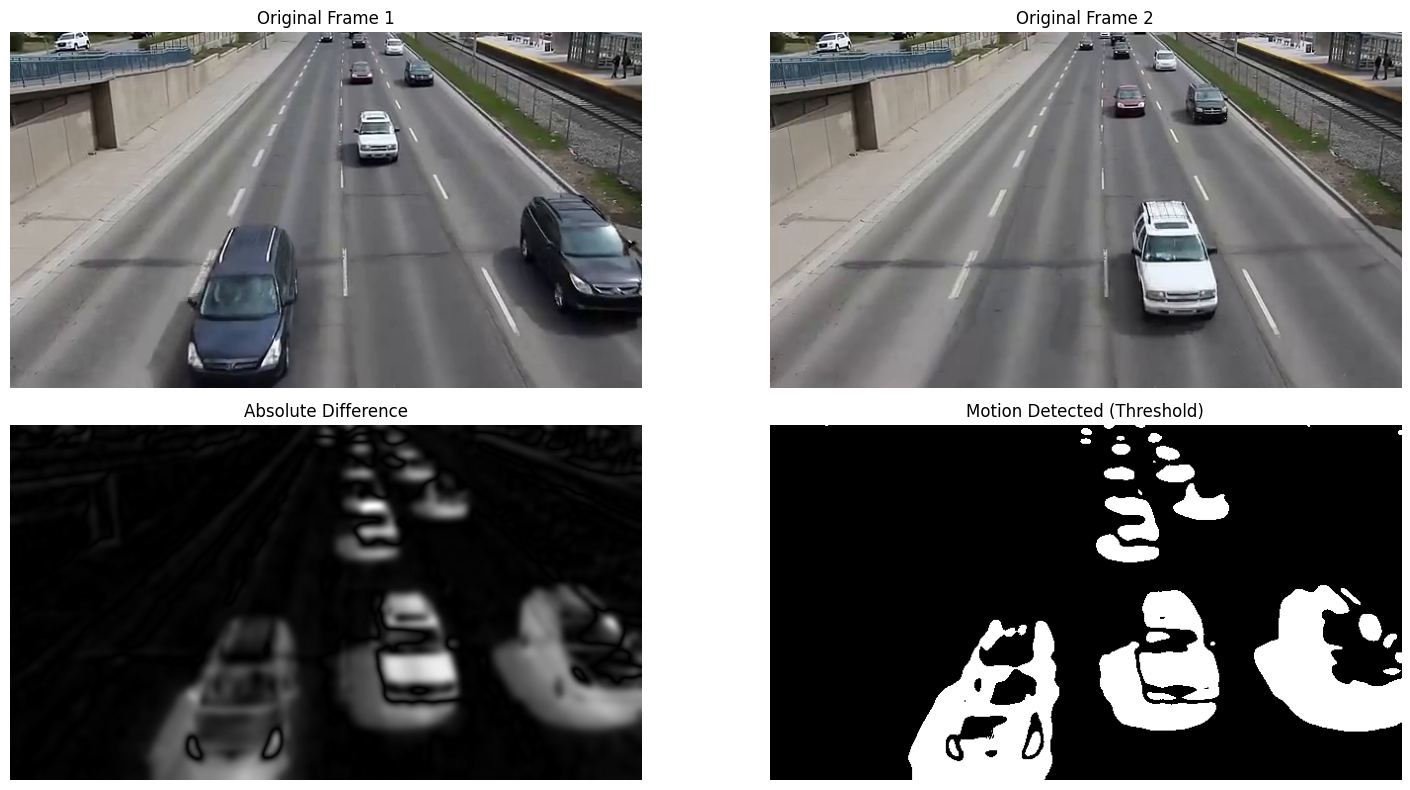

In [ ]:

# رابط الفيديو
video_url = "https://raw.githubusercontent.com/mohres/aleppo-vision-course-assets/master/videos/passing-cars.mp4"

# تحميل الفيديو
video_path = "passing-cars.mp4"

response = requests.get(video_url)

with open(video_path, "wb") as f:
    f.write(response.content)

# فتح الفيديو
cap = cv2.VideoCapture(video_path)

# قراءة أول إطار
ret1, frame1 = cap.read()

# قراءة عدة إطارات لاحقاً للحصول على حركة واضحة
for _ in range(20):
    ret2, frame2 = cap.read()

if not ret1 or not ret2:
    print("فشل في قراءة الإطارات من الفيديو.")
else:
    # تحويل الإطارات إلى رمادي
    gray_frame1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray_frame2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    # 1. تنعيم الإطارات لتقليل الضوضاء
    gray1 = cv2.GaussianBlur(gray_frame1, (21, 21), 0)
    gray2 = cv2.GaussianBlur(gray_frame2, (21, 21), 0)

    # 2. حساب الفرق المطلق بين الإطارين
    frame_delta = cv2.absdiff(gray1, gray2)

    # 3. تطبيق Threshold لاكتشاف الحركة
    _, thresh = cv2.threshold(frame_delta, 25, 255, cv2.THRESH_BINARY)

    # تحويل الصور من BGR إلى RGB للعرض الصحيح
    frame1_rgb = cv2.cvtColor(frame1, cv2.COLOR_BGR2RGB)
    frame2_rgb = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)

    # 4. عرض النتائج
    plt.figure(figsize=(16, 8))

    # الإطار الأصلي الأول
    plt.subplot(2, 2, 1)
    plt.imshow(frame1_rgb)
    plt.title('Original Frame 1')
    plt.axis('off')

    # الإطار الأصلي الثاني
    plt.subplot(2, 2, 2)
    plt.imshow(frame2_rgb)
    plt.title('Original Frame 2')
    plt.axis('off')

    # الفرق بين الإطارين
    plt.subplot(2, 2, 3)
    plt.imshow(frame_delta, cmap='gray')
    plt.title('Absolute Difference')
    plt.axis('off')

    # الحركة المكتشفة
    plt.subplot(2, 2, 4)
    plt.imshow(thresh, cmap='gray')
    plt.title('Motion Detected (Threshold)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# تحرير الفيديو
cap.release()

<div dir="rtl">

---

### الطريقة 2: طرح الخلفية الديناميكي (Background Subtraction)

بدلاً من الطرح من الإطار السابق، نقوم ببناء **"نموذج تخيلي للخلفية الثابتة"** (Background Model) خالية من أي أجسام متحركة، ونطرح كل إطار جديد من هذه الخلفية المحفوظة.

ولأن الشمس تتحرك والإضاءة تتغير طوال اليوم، يجب أن تتغير الخلفية وتتعلم بذكاء تدريجياً عبر هذه المعادلة التكيفية:

$$B_t(x, y) = \alpha \cdot I_t(x, y) + (1 - \alpha) \cdot B_{t-1}(x, y)$$

حيث يمثل $\alpha$ **معدل التعلم (Learning Rate)** ويترواح عادة بين $0.01$ و $0.05$. هذا يعني أن الخلفية تأخذ جزءاً صغيراً جداً من الإطار الجديد وتدمجه في ذاكرتها، فإذا وقف شخص في الشارع لفترة طويلة، سيتلاشى تدريجياً ويصبح جزءاً من الخلفية الثابتة!

توفر مكتبة OpenCV خوارزميات جاهزة وذكية جداً مبنية على الإحصاء مثل **MOG2** و **KNN**، والتي تستطيع عزل ظلال الأجسام حتى لا تحسبها كحركة خاطئة.

</div>


Frame 0


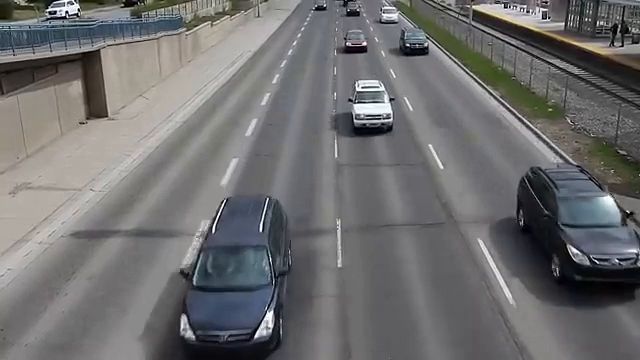

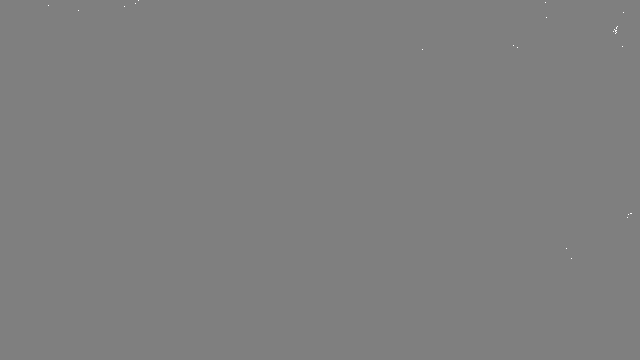

--------------------------------------------------
Frame 30


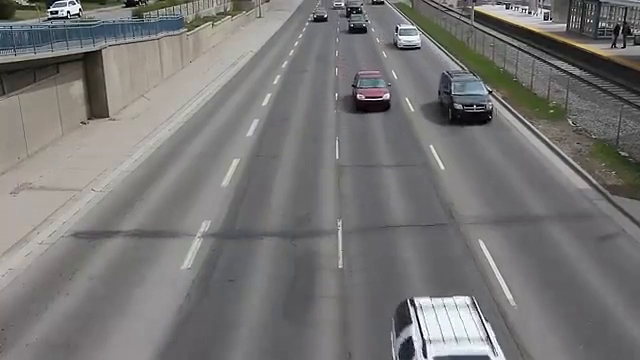

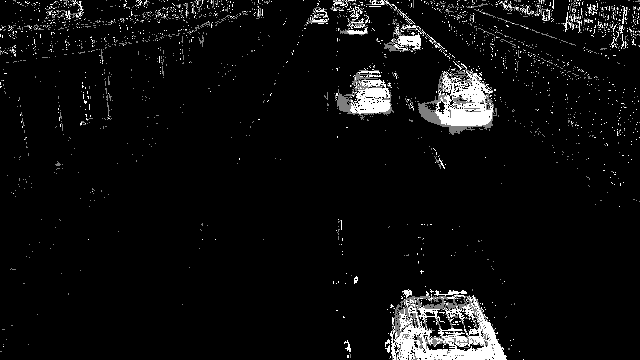

--------------------------------------------------


In [ ]:
from google.colab.patches import cv2_imshow
import cv2

# إنشاء كائن طرح الخلفية باستخدام MOG2
back_sub = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=True
)

# استخدام نفس الفيديو
video_path = "passing-cars.mp4"

cap = cv2.VideoCapture(video_path)

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break

    # تطبيق خوارزمية طرح الخلفية
    fg_mask = back_sub.apply(frame)

    # لتجنب عرض عدد هائل من الإطارات في Colab
    # نعرض إطاراً كل 30 إطار تقريباً
    if frame_count % 30 == 0:

        print(f"Frame {frame_count}")

        # عرض الفيديو الأصلي
        cv2_imshow(frame)

        # عرض قناع الحركة
        cv2_imshow(fg_mask)

        print("-" * 50)

    frame_count += 1

cap.release()

<div dir="rtl">

---

### الطريقة 3: التدفق البصري (Optical Flow) — مقدمة

الطرق السابقة تجيب على سؤال: *"هل هناك شيء يتحرك؟"*. أما التدفق البصري فيجيب على سؤال أعمق وأكثر ذكاءً: **"إلى أين وبأي سرعة يتحرك كل بكسل في الصورة؟"**

الخوارزمية تبحث عن البكسلات المميزة في الإطار الأول (مثل الزوايا والنقاط الحادة) وتتعقب موقعها الجديد في الإطار التالي، مما ينتج عنه **متجهات حركة (Vectors)** تمثل اتجاه وسرعة الأجسام.

تعتمد هذه الطريقة رياضياً على قانون قيد التدفق البصري (**Lucas-Kanade method**):

$$I_x \cdot u + I_y \cdot v + I_t = 0$$

حيث أن ($I_x, I_y$) هي تدرجات الألوان التي حسبناها سابقاً في فلتر سوبل، و ($I_t$) هو التغير عبر الزمن، بينما ($u, v$) هي السرعات المجهولة للبكسل في اتجاه $x$ و $y$ والتي تبحث عنها الخوارزمية.

</div>


Frame 0


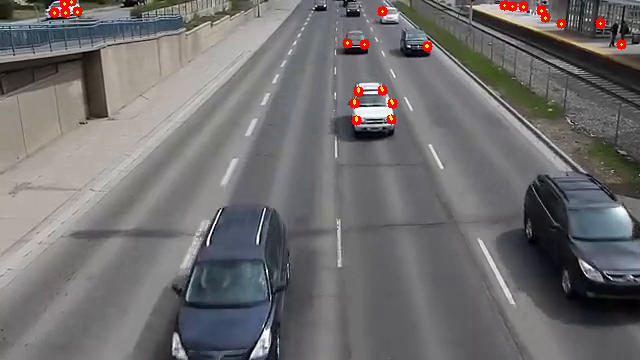

--------------------------------------------------
Frame 30


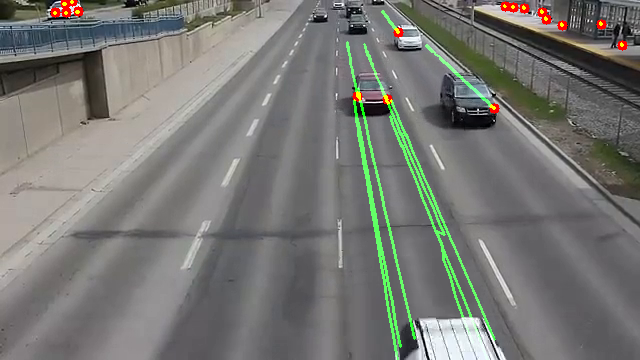

--------------------------------------------------


In [ ]:
# استخدام نفس الفيديو
video_path = "passing-cars.mp4"

cap = cv2.VideoCapture(video_path)

# بارامترات اكتشاف الزوايا (Shi-Tomasi)
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

# بارامترات Lucas-Kanade Optical Flow
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
)

# قراءة أول إطار
ret, old_frame = cap.read()



# تحويل أول إطار إلى رمادي
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# استخراج النقاط المهمة للتتبع
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

# صورة لرسم مسارات الحركة
mask = np.zeros_like(old_frame)

frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # حساب Optical Flow
    p1, st, err = cv2.calcOpticalFlowPyrLK(
        old_gray,
        frame_gray,
        p0,
        None,
        **lk_params
    )

    # التأكد من نجاح التتبع
    if p1 is not None:

        good_new = p1[st == 1]
        good_old = p0[st == 1]

        # رسم الحركة
        for new, old in zip(good_new, good_old):

            a, b = new.ravel()
            c, d = old.ravel()

            # رسم خط الحركة
            mask = cv2.line(
                mask,
                (int(a), int(b)),
                (int(c), int(d)),
                (0, 255, 0),
                2
            )

            # رسم النقطة الحالية
            frame = cv2.circle(
                frame,
                (int(a), int(b)),
                5,
                (0, 0, 255),
                -1
            )

        # دمج الصورة مع المسارات
        img = cv2.add(frame, mask)

        # عرض إطار كل 30 إطار لتجنب إغراق Colab
        if frame_count % 30 == 0:

            print(f"Frame {frame_count}")

            cv2_imshow(img)

            print("-" * 50)

        # تحديث الإطار السابق والنقاط السابقة
        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

    frame_count += 1

cap.release()

<div dir="rtl">

---

### مقارنة بين الطرق الثلاث

| الطريقة | السرعة الحسابية | الدقة وعزل الضوضاء | متى وأين تستخدمها؟ |
| :--- | :--- | :--- | :--- |
| **Frame Differencing** | عالية السرعة | منخفضة جداً وتتأثر بالاهتزاز | المعالجات الضعيفة جداً، كاميرات الـ Raspberry Pi البسيطة، مستشعرات الحركة البدائية. |
| **Background Subtraction** | متوسطة إلى سريعة | متوسطة إلى عالية (تتحمل تغيرات الطقس) | أنظمة المراقبة الثابتة (أمن المحلات، عد السيارات في الشوارع، حراسة المداخل). |
| **Optical Flow** | بطيئة ومكثفة حسابياً | دقيقة جداً (تعطي الاتجاه والسرعة) | تتبع الأجسام الذكي (Object Tracking)، خوارزميات القيادة الذاتية للسيارات، تحليل سلوك المشاة. |

</div>


<div dir="rtl">

---

## كيف تترابط المواضيع الثلاثة؟ (The Big Picture)

هذه المواضيع الثلاثة لا تعمل باستقلالية — تترابط معاً في خط إنتاج متكامل. تخيل كاميرا مراقبة ذكية تكتشف سيارة وتقرأ لوحتها:

---

### خط الإنتاج داخل الكمبيوتر (Pipeline)

#### 1. الفلترة (Gaussian) — تنظيف البيانات
الإطارات القادمة من الكاميرا مليئة بالضوضاء. **فلتر Gaussian** يُنعّمها أولاً لحماية كل مرحلة لاحقة من قرارات خاطئة مبنية على تشويش عابر.

#### 2. كشف الحركة (Background Subtraction) — تحديد منطقة الاهتمام
بعد التنظيف، يطرح النظام الخلفية الثابتة فيتحول كل شيء ساكن إلى أسود وتضيء السيارة المتحركة وحدها. هذا يُهمل 90% من مساحة الصورة ويُركّز الحسابات على الجسم المتحرك فقط.

#### 3. كشف الحواف (Canny/Sobel) — استخراج الشكل والمعالم
الكتلة البيضاء تمثل السيارة لكنها لا تزال بلا تفاصيل. **Canny** يُحوّلها إلى رسم هندسي واضح الحواف — وهو ما تقرأ منه خوارزميات لاحقة رقم اللوحة أو نوع السيارة.

---

### ملخص الترابط الهرمي

الرؤية الحاسوبية الكلاسيكية تبنى دائماً من الأسفل إلى الأعلى:

$$\text{Image Filtering (Gaussian)} \longrightarrow \text{Motion Detection (Background Subtraction)} \longrightarrow \text{Edge Detection (Sobel/Canny)}$$

1. **الفلترة:** تحسن جودة البكسلات الفردية.
2. **كشف الحركة:** يجمع البكسلات المتغيرة عبر **الزمن** ليعزل الكائن المتحرك.
3. **كشف الحواف:** يدرس المظهر الهيكلي في **المساحة (الأبعاد)** ليعطي الكائن شكلاً مفهوماً.

> 💡 **درس للمستقبل:** بدون **الفلترة**، سيفشل **كشف الحركة** بسبب الضوضاء. وبدون كشف الحركة، ستتشتت خوارزمية **كشف الحواف** في تفاصيل الخلفية غير المهمة. هذا التناغم هو سر قوة الرؤية الحاسوبية!

</div>

<div dir="rtl">

---

## تمرينات عملية

### تمرين 1: كشف الحواف بدون Gaussian
جرّب تطبيق Canny مباشرةً على الصورة الرمادية بدون تنعيم مسبق — قارن النتيجة مع النتيجة المنعّمة وشاهد كيف تصبح الحواف مليئة بالضوضاء.

### تمرين 2: مقارنة الفلاتر الثلاثة
طبّق فلاتر Gaussian وMedian وLaplacian على نفس الصورة في خلية الكود التالية وقارن النتائج بصرياً — هذا يُرسّخ "القاعدة الذهبية" الخاصة باختيار الفلتر المناسب.

</div>

In [ ]:
# تمرين 1: كشف الحواف بدون Gaussian — قارن النتيجة مع النتيجة المنعّمة
# الخطوة 1: تطبيق Canny مباشرةً على الصورة الرمادية (بدون تنعيم)
edges_no_gaussian = cv2.Canny(img_gray, 50, 150)

# الخطوة 2: تطبيق Canny بعد التنعيم (النتيجة الصحيحة)
edges_with_gaussian = cv2.Canny(img_smoothed, 50, 150)

# عرض المقارنة
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(edges_no_gaussian, cmap='gray')
axes[0].set_title('Canny WITHOUT Gaussian (noisy edges)', fontsize=13)
axes[0].axis('off')

axes[1].imshow(edges_with_gaussian, cmap='gray')
axes[1].set_title('Canny WITH Gaussian (clean edges)', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# تمرين 2: مقارنة فلاتر Gaussian و Median و Laplacian على نفس الصورة
# نُضيف أولاً ضوضاء ملح وفلفل (Salt & Pepper) للصورة لنرى فرق الفلاتر بوضوح

import numpy as np

# إضافة ضوضاء ملح وفلفل
def add_salt_pepper_noise(image, amount=0.02):
    noisy = image.copy()
    num_pixels = int(amount * image.size)
    # ضوضاء الملح (بيضاء)
    coords = [np.random.randint(0, i, num_pixels) for i in image.shape]
    noisy[tuple(coords)] = 255
    # ضوضاء الفلفل (سوداء)
    coords = [np.random.randint(0, i, num_pixels) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

img_noisy = add_salt_pepper_noise(img_gray, amount=0.03)

# تطبيق الفلاتر الثلاثة
gaussian_result  = cv2.GaussianBlur(img_noisy, (5, 5), 0)
median_result    = cv2.medianBlur(img_noisy, 5)
laplacian_result = cv2.Laplacian(img_gray, cv2.CV_64F)
laplacian_display = cv2.convertScaleAbs(laplacian_result)

# العرض المقارن
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

titles = ['Original + Noise', 'Gaussian Filter', 'Median Filter', 'Laplacian Filter']
images = [img_noisy, gaussian_result, median_result, laplacian_display]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Filter Comparison — Same Image, Different Filters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("لاحظ: Gaussian ينعّم الضوضاء لكنه يبقي بعض التشويش | Median يمسح نقاط الملح والفلفل تماماً | Laplacian يُبرز الحواف فقط")